# Value-Bin-by-Delay MVPA — Function Review Notebook

Walk through each new function in execution order, validate shapes and outputs,
and check that the full pipeline hangs together before submitting Slurm jobs.

**Functions covered (in order):**
1. `compute_global_bin_edges` — pool all subjects' trials and find global tertile cut-points
2. `assign_bin_labels` — label each trial with its delay bin and value bin
3. `build_subject_binned_roi_patterns` — extract betas for one subject and average within bins
4. `nested_loso_multiclass_logreg_predict` — LOSO logistic classifier (small-scale smoke test)
5. `decode_value_bins_by_delay` — full pipeline for one delay bin across all subjects
6. Output format preview

Run sections 1–3 before committing to the full run; they are fast (a few minutes each on a login node **only for a small subset** — do not load all subjects' betas on the login node).

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dd_kable_analysis.config_loader import load_config
from dd_kable_analysis.mvpa import (
    build_subject_behav_bold_df,
    decode_value_bins_by_delay,
)
from dd_kable_analysis.mvpa.atlas import resolve_atlas
from dd_kable_analysis.mvpa.data_binned import (
    assign_bin_labels,
    build_subject_binned_roi_patterns,
    compute_global_bin_edges,
)
from dd_kable_analysis.mvpa.models import nested_loso_multiclass_logreg_predict

cfg = load_config()
atlas_img, atlas_source = resolve_atlas(cfg, 'pauli_rois', None)
print('Atlas:', atlas_source)

Atlas: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/masks/pauli_subcort_rois_neurovault_collection_3145/pauli_roi_atlas_thr0.50_to-groupmask.nii.gz


In [2]:
# Use a small subset for fast testing — do NOT load all 123 subjects here.
# Increase N_REVIEW_SUBS when you're happy and want to test the full decode step.
from pathlib import Path

sub_list_path = Path(cfg.data_root) / 'subject_lists' / 'mvpa_subject_list.txt'
all_sub_ids = [s.strip() for s in sub_list_path.read_text().splitlines() if s.strip()]

N_REVIEW_SUBS = 15  # change to len(all_sub_ids) when ready for full run
sub_ids = all_sub_ids[:N_REVIEW_SUBS]
print(f'Using {len(sub_ids)} subjects: {sub_ids[:5]} ...')

Using 15 subjects: ['dmp0011', 'dmp0019', 'dmp0048', 'dmp0060', 'dmp0062'] ...


---
## 1. `compute_global_bin_edges`

**What it does:** Pools all trials from all subjects, computes the 33rd and 67th percentile
of `Delay` and `amount` separately. Returns two arrays of shape `(2,)` — the interior bin edges.

**Why global:** Using global edges ensures a trial with Delay=30 lands in the same bin
regardless of which subject it came from.

**Location:** `src/dd_kable_analysis/mvpa/data_binned.py` — `compute_global_bin_edges()`

In [3]:
# Step 1a: load behavioral data (no betas) for each subject
beh_results = {}
failed_subs = []

for sub_id in sub_ids:
    try:
        beh_results[sub_id] = build_subject_behav_bold_df(
            cfg, sub_id=sub_id, y_col='amount', verbose=False, strict=False
        )
    except RuntimeError as e:
        print(f'Skipping {sub_id}: {e}')
        failed_subs.append(sub_id)

trial_dfs = [beh_results[s].behav_bold_df for s in beh_results]
print(
    f'Total trials across {len(beh_results)} subjects: {sum(len(df) for df in trial_dfs)}'
)
print(f'Failed subjects ({len(failed_subs)}): {failed_subs}')

Skipping dmp0063: ❌ 16 trials for sub dmp0063, run 2 are clipped. Cannot generate design matrix.
Total trials across 14 subjects: 1562
Failed subjects (1): ['dmp0063']


In [4]:
len(trial_dfs)

14

Delay tertile edges: [ 74. 128.]
Value tertile edges: [35. 58.]


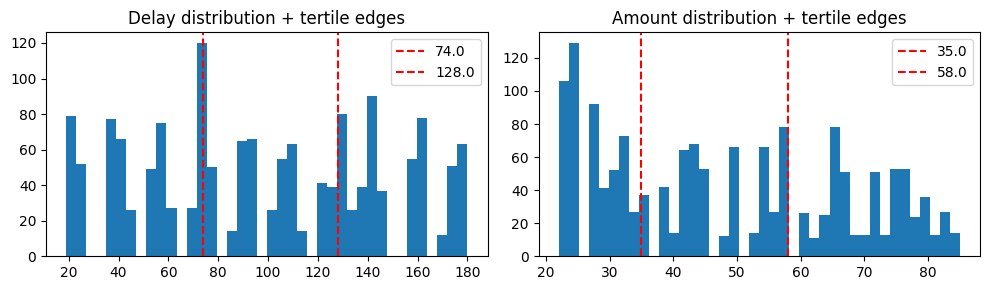

In [5]:
# Step 1b: compute edges
delay_edges, value_edges = compute_global_bin_edges(trial_dfs)

print('Delay tertile edges:', delay_edges)
print('Value tertile edges:', value_edges)

# Sanity check: pool all delays and values, verify edge positions
all_delays = pd.concat([df['Delay'] for df in trial_dfs]).dropna()
all_values = pd.concat([df['amount'] for df in trial_dfs]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(all_delays, bins=40)
for e in delay_edges:
    axes[0].axvline(e, color='r', linestyle='--', label=f'{e:.1f}')
axes[0].set_title('Delay distribution + tertile edges')
axes[0].legend()

axes[1].hist(all_values, bins=40)
for e in value_edges:
    axes[1].axvline(e, color='r', linestyle='--', label=f'{e:.1f}')
axes[1].set_title('Amount distribution + tertile edges')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 2. `assign_bin_labels`

**What it does:** Takes a trial DataFrame and the edges from step 1, adds integer columns
`delay_bin` (1/2/3) and `value_bin` (1/2/3) to each trial.

**Location:** `src/dd_kable_analysis/mvpa/data_binned.py` — `assign_bin_labels()`

### Important note
Granted this is just one subject, but I think it will be similar for other subjects. The delay bins are:
* D1: 19–73 days
* D2: 74–126 days
* D3: 128–180 days

I believe the first delay bin isn't necessarily considered a "short" delay.  We need the trial numbers to be comparable for the predcition model. 

In [6]:
# Demonstrate on one subject
example_sub = sub_ids[0]
df_example = beh_results[example_sub].behav_bold_df
df_binned = assign_bin_labels(df_example, delay_edges, value_edges)

print('Columns added:', [c for c in df_binned.columns if 'bin' in c])
print('\nCell counts (delay_bin × value_bin):')
print(df_binned.groupby(['delay_bin', 'value_bin']).size().unstack(fill_value=0))
print('\nDelay ranges per bin:')
print(df_binned.groupby('delay_bin')['Delay'].agg(['min', 'max', 'count']))
print('\nAmount ranges per bin:')
print(df_binned.groupby('value_bin')['amount'].agg(['min', 'max', 'count']))

Columns added: ['delay_bin', 'value_bin']

Cell counts (delay_bin × value_bin):
value_bin   1   2   3
delay_bin            
1          12   9  16
2          16  10  13
3          10  16  14

Delay ranges per bin:
           min  max  count
delay_bin                 
1           19   73     37
2           74  126     39
3          128  180     40

Amount ranges per bin:
           min  max  count
value_bin                 
1           22   34     38
2           35   57     35
3           58   85     43


---
## 3. `build_subject_binned_roi_patterns`

**What it does:** For one subject:
- Loads beta-series NIfTIs and extracts voxel patterns within each ROI
- Runs run-aware voxel QC per ROI (computes the valid-voxel mask but does **not** filter yet)
- Averages beta patterns within each delay × value bin cell
- Returns a `SubjectBinnedData` object with:
  - `roi_patterns[delay_bin][roi_label]` — float32 array (n_value_bins, n_vox_roi)
  - `roi_valid_voxels[roi_label]` — bool mask for cross-subject intersection at decode time
  - `bin_trial_counts[delay_bin][roi_label]` — int array (n_value_bins,)
  - `excluded_delay_bins` — list of delay bins that had too few trials in some cell

**Location:** `src/dd_kable_analysis/mvpa/data_binned.py` — `build_subject_binned_roi_patterns()`


In [7]:
# Load binned patterns for ONE subject to inspect output
sd = build_subject_binned_roi_patterns(
    cfg,
    sub_id=sub_ids[0],
    atlas_img=atlas_img,
    delay_edges=delay_edges,
    value_edges=value_edges,
    behav_bold_result=beh_results[sub_ids[0]],  # reuse already-loaded table
    verbose=True,
)

print('\n--- SubjectBinnedData summary ---')
print('sub_id:', sd.sub_id)
print('excluded_delay_bins:', sd.excluded_delay_bins)
print('valid delay bins:', sorted(sd.roi_patterns.keys()))
print('ROIs with patterns (delay_bin=1):', sorted(sd.roi_patterns.get(1, {}).keys()))
print('n_vox_total per ROI:', sd.n_vox_total)
print(
    'valid voxels per ROI:', {k: int(v.sum()) for k, v in sd.roi_valid_voxels.items()}
)

[global] X_all=(116, 240143) (mask vox=240143) y=(116,) groups=(116,)
[global] trials per run:
 1    29
2    29
3    29
4    29
[roi map] n_rois=16
[roi map] voxels per ROI percentiles: [   2.    8.   54. 1463. 1655.]

--- SubjectBinnedData summary ---
sub_id: dmp0011
excluded_delay_bins: []
valid delay bins: [1, 2, 3]
ROIs with patterns (delay_bin=1): [1, 2, 3, 5, 8, 14]
n_vox_total per ROI: {1: 1655, 2: 1399, 3: 122, 5: 221, 6: 123, 8: 92, 9: 69, 14: 183}
valid voxels per ROI: {1: 1641, 2: 1369, 3: 112, 5: 36, 8: 1, 14: 120}


In [8]:
sd

SubjectBinnedData(sub_id='dmp0011', roi_patterns={1: {1: array([[ 0.33014435,  0.41159257,  0.02298462, ..., -0.6074088 ,
        -0.4888953 , -0.5607895 ],
       [ 0.8733989 ,  1.4236999 ,  0.8806701 , ..., -0.894838  ,
        -0.70560855, -0.6370749 ],
       [-0.7777322 ,  0.3196778 ,  0.05242783, ..., -0.31635916,
        -0.4316952 , -0.35041997]], shape=(3, 1655), dtype=float32), 2: array([[ 0.7151567 ,  0.68631816,  0.16236329, ...,  0.46645096,
         0.8549221 ,  0.504397  ],
       [ 1.7709152 ,  0.32829106,  0.6373485 , ...,  0.78681576,
         0.5514536 ,  1.0613288 ],
       [ 0.12263604, -0.24963285, -0.4894158 , ...,  0.971622  ,
         0.2507096 ,  1.0511757 ]], shape=(3, 1399), dtype=float32), 3: array([[ 1.60258114e+00,  4.33517158e-01,  1.11558342e+00,
         3.98763478e-01, -3.83328527e-01, -3.58815461e-01,
        -4.96592522e-01,  3.17202777e-01,  1.63309038e-01,
        -7.33123243e-01,  1.03531875e-01,  1.14456944e-01,
        -4.93881911e-01,  2.01922

In [9]:
# Inspect pattern shape and trial counts for one ROI
example_roi = sorted(sd.roi_patterns.get(1, {}).keys())[0]
pattern = sd.roi_patterns[1][example_roi]
counts = sd.bin_trial_counts[1][example_roi]

print(f'ROI {example_roi}, delay_bin=1:')
print(f'  pattern shape: {pattern.shape}  (n_value_bins × n_voxels)')
print(f'  trial counts per value bin: {counts}')
print(f'  pattern mean per value bin: {pattern.mean(axis=1).round(4)}')
print(f'  pattern std  per value bin: {pattern.std(axis=1).round(4)}')

ROI 1, delay_bin=1:
  pattern shape: (3, 1655)  (n_value_bins × n_voxels)
  trial counts per value bin: [12  9 16]
  pattern mean per value bin: [ 0.1338  0.4198 -0.0268]
  pattern std  per value bin: [0.654  0.7185 0.5304]


---
## 4. `nested_loso_multiclass_logreg_predict`

**What it does:** Takes an X matrix (n_patterns × n_voxels), integer labels y, and subject
group IDs; runs leave-one-subject-out nested CV with inner C tuning. Returns:
- `y_proba_oos` — (n_patterns, n_classes) OOS predicted probabilities
- `y_pred_oos` — (n_patterns,) OOS hard predictions
- `info` — dict with balanced accuracy, per-class P/R/F1/AUC, confusion matrix

**Key parameters:**
- `groups` — subject IDs; all patterns from one subject leave together
- `Cs` — log grid of inverse regularisation strengths (default: 10^{-4} to 10^4, 17 steps)
- `max_iter=2000` — LBFGS iterations; increase if you see convergence warnings

**Location:** `src/dd_kable_analysis/mvpa/models.py` — `nested_loso_multiclass_logreg_predict()`

This cell uses **synthetic data** so it runs instantly on the login node.

In [10]:
# Synthetic smoke test: 20 subjects × 3 patterns, 100 voxels, 3 classes
rng = np.random.default_rng(42)
N_SUBS_FAKE = 20
N_VOX_FAKE = 100
N_VAL_BINS = 3

# Give classes slightly different means so the classifier has something to learn
X_fake = rng.normal(size=(N_SUBS_FAKE * N_VAL_BINS, N_VOX_FAKE))
for v in range(N_VAL_BINS):
    idx = np.arange(v, N_SUBS_FAKE * N_VAL_BINS, N_VAL_BINS)
    X_fake[idx, :20] += (v - 1) * 0.8  # small signal in first 20 voxels

y_fake = np.tile(np.arange(1, N_VAL_BINS + 1), N_SUBS_FAKE)
groups_fake = np.repeat([f'sub{i:03d}' for i in range(N_SUBS_FAKE)], N_VAL_BINS)

print(
    f'X shape: {X_fake.shape}  y unique: {np.unique(y_fake)}  n_groups: {len(np.unique(groups_fake))}'
)

y_proba, y_pred, info = nested_loso_multiclass_logreg_predict(
    X_fake, y_fake, groups_fake, verbose=False
)

print(f'\nOutput shapes:')
print(
    f'  y_proba_oos: {y_proba.shape}  (should be {N_SUBS_FAKE * N_VAL_BINS} × {N_VAL_BINS})'
)
print(f'  y_pred_oos:  {y_pred.shape}')
print(f'  proba rows sum to 1: {np.allclose(y_proba.sum(axis=1), 1.0)}')

print(f'\nKey metrics:')
print(f'  chance level:     {info["chance_level"]:.3f}')
print(f'  accuracy:         {info["accuracy"]:.3f}')
print(f'  balanced_accuracy:{info["balanced_accuracy"]:.3f}')
print(f'  mean_C:           {info["mean_C"]:.4g}')

print(f'\nPer-class metrics (precision / recall / F1 / AUC):')
for j, cls in enumerate(info['classes']):
    print(
        f'  A{cls}: P={info["precision"][j]:.3f}  R={info["recall"][j]:.3f}  '
        f'F1={info["f1"][j]:.3f}  AUC={info["auc_per_class"][j]:.3f}'
    )

print(f'\nConfusion matrix (rows=true, cols=pred):')
cm_arr = np.array(info['confusion_matrix'])
print(
    pd.DataFrame(
        cm_arr,
        index=[f'true_A{c}' for c in info['classes']],
        columns=[f'pred_A{c}' for c in info['classes']],
    )
)

X shape: (60, 100)  y unique: [1 2 3]  n_groups: 20

Output shapes:
  y_proba_oos: (60, 3)  (should be 60 × 3)
  y_pred_oos:  (60,)
  proba rows sum to 1: True

Key metrics:
  chance level:     0.333
  accuracy:         0.700
  balanced_accuracy:0.700
  mean_C:           0.08974

Per-class metrics (precision / recall / F1 / AUC):
  A1: P=0.810  R=0.850  F1=0.829  AUC=0.944
  A2: P=0.545  R=0.600  F1=0.571  AUC=0.636
  A3: P=0.765  R=0.650  F1=0.703  AUC=0.946

Confusion matrix (rows=true, cols=pred):
         pred_A1  pred_A2  pred_A3
true_A1       17        3        0
true_A2        4       12        4
true_A3        0        7       13


---
## 5. `decode_value_bins_by_delay`

**What it does:** High-level function that, for a given delay bin:
1. Filters to subjects with valid patterns for that delay level
2. For each ROI, computes the cross-subject voxel intersection (AND of per-subject QC masks)
3. Stacks X across subjects: shape (n_subjects × n_value_bins, n_common_voxels)
4. Calls `nested_loso_multiclass_logreg_predict`
5. Returns three DataFrames: `roi_summary_df`, `subject_preds_df`, `confusion_df`

**Location:** `src/dd_kable_analysis/mvpa/decode.py` — `decode_value_bins_by_delay()`

⚠️ **The cell below is a SMALL-SCALE test** — only the N subjects loaded above.
The full run across all 123 subjects runs via `submit_value_bins_by_delay.sh`.

To run this cell you need the subjects' betas already loaded (i.e., you ran section 3 cells
for multiple subjects). The easiest path is to run the loop below for all `sub_ids`.

In [11]:
# Build binned patterns for all N_REVIEW_SUBS subjects
# (skip subjects already loaded if you re-run cells)
all_subject_data = []
for sub_id in beh_results.keys():
    try:
        sd = build_subject_binned_roi_patterns(
            cfg,
            sub_id=sub_id,
            atlas_img=atlas_img,
            delay_edges=delay_edges,
            value_edges=value_edges,
            behav_bold_result=beh_results[sub_id],
            verbose=False,
        )
        all_subject_data.append(sd)
    except Exception as e:
        print(f'Skipping {sub_id}: {e}')

print(f'Built binned data for {len(all_subject_data)} subjects')

Built binned data for 14 subjects


In [12]:
all_subject_data

[SubjectBinnedData(sub_id='dmp0011', roi_patterns={1: {1: array([[ 0.33014435,  0.41159257,  0.02298462, ..., -0.6074088 ,
         -0.4888953 , -0.5607895 ],
        [ 0.8733989 ,  1.4236999 ,  0.8806701 , ..., -0.894838  ,
         -0.70560855, -0.6370749 ],
        [-0.7777322 ,  0.3196778 ,  0.05242783, ..., -0.31635916,
         -0.4316952 , -0.35041997]], shape=(3, 1655), dtype=float32), 2: array([[ 0.7151567 ,  0.68631816,  0.16236329, ...,  0.46645096,
          0.8549221 ,  0.504397  ],
        [ 1.7709152 ,  0.32829106,  0.6373485 , ...,  0.78681576,
          0.5514536 ,  1.0613288 ],
        [ 0.12263604, -0.24963285, -0.4894158 , ...,  0.971622  ,
          0.2507096 ,  1.0511757 ]], shape=(3, 1399), dtype=float32), 3: array([[ 1.60258114e+00,  4.33517158e-01,  1.11558342e+00,
          3.98763478e-01, -3.83328527e-01, -3.58815461e-01,
         -4.96592522e-01,  3.17202777e-01,  1.63309038e-01,
         -7.33123243e-01,  1.03531875e-01,  1.14456944e-01,
         -4.9388191

In [13]:
# Run the full decode for delay_bin=1 using the small subject set
# min_subjects_per_roi is set low here to ensure ROIs aren't skipped with only 15 subjects
roi_summary_df, subject_preds_df, confusion_df = decode_value_bins_by_delay(
    all_subject_data,
    delay_bin=1,
    min_subjects_per_roi=5,  # lower threshold for review; use 10+ in production
    verbose=True,
)

print(f'\nroi_summary_df shape: {roi_summary_df.shape}')
print(f'subject_preds_df shape: {subject_preds_df.shape}')
print(f'confusion_df shape: {confusion_df.shape}')

[delay_bin=1] 14/14 subjects have data
  ROI 1: n_subs=14 X=(42, 1380) n_vox_common=1380
  ROI 2: n_subs=14 X=(42, 1346) n_vox_common=1346
  ROI 3: dropped 1 subject(s) with < 20 valid voxels
  ROI 3: n_subs=13 X=(39, 49) n_vox_common=49
  ROI 5: dropped 1 subject(s) with < 20 valid voxels
  ROI 5: n_subs=13 X=(39, 21) n_vox_common=21
  ROI 6: dropped 1 subject(s) with < 20 valid voxels
  ROI 6: only 6 voxels after intersection, need 20, skipping
  ROI 8: dropped 2 subject(s) with < 20 valid voxels
  ROI 8: n_subs=11 X=(33, 32) n_vox_common=32
  ROI 9: dropped 2 subject(s) with < 20 valid voxels
  ROI 9: only 8 voxels after intersection, need 20, skipping
  ROI 14: n_subs=14 X=(42, 59) n_vox_common=59

roi_summary_df shape: (6, 21)
subject_preds_df shape: (237, 9)
confusion_df shape: (54, 5)


In [14]:
confusion_df

,roi_label,delay_bin,true_class,pred_class,count
0,1,1,1,1,7
1,1,1,1,2,1
2,1,1,1,3,6
3,1,1,2,1,6
4,1,1,2,2,2
5,1,1,2,3,6
6,1,1,3,1,5
7,1,1,3,2,3
8,1,1,3,3,6
9,2,1,1,1,11


---
## 6. Output Format Preview

Inspect the three output DataFrames that will be written to disk by the Slurm entry point.
These are the files you'll load in the aggregation notebook.

In [15]:
print('=== roi_summary_df (one row per ROI) ===')
print('Shape:', roi_summary_df.shape)
print('Columns:', roi_summary_df.columns.tolist())
roi_summary_df

=== roi_summary_df (one row per ROI) ===
Shape: (6, 21)
Columns: ['roi_label', 'delay_bin', 'n_subjects', 'n_patterns', 'n_vox', 'chance_level', 'accuracy', 'balanced_accuracy', 'mean_C', 'precision_A1', 'recall_A1', 'f1_A1', 'auc_A1', 'precision_A2', 'recall_A2', 'f1_A2', 'auc_A2', 'precision_A3', 'recall_A3', 'f1_A3', 'auc_A3']


,roi_label,delay_bin,n_subjects,n_patterns,n_vox,chance_level,accuracy,balanced_accuracy,mean_C,precision_A1,...,f1_A1,auc_A1,precision_A2,recall_A2,f1_A2,auc_A2,precision_A3,recall_A3,f1_A3,auc_A3
0,1,1,14,42,1380,0.333333,0.357143,0.357143,0.000180,0.388889,...,0.437500,0.535714,0.333333,0.142857,0.200000,0.563776,0.333333,0.428571,0.375000,0.594388
1,2,1,14,42,1346,0.333333,0.452381,0.452381,0.000115,0.458333,...,0.578947,0.599490,0.000000,0.000000,0.000000,0.272959,0.444444,0.571429,0.500000,0.632653
2,3,1,13,39,49,0.333333,0.256410,0.256410,0.001111,0.214286,...,0.222222,0.352071,0.461538,0.461538,0.461538,0.556213,0.083333,0.076923,0.080000,0.393491
3,5,1,13,39,21,0.333333,0.307692,0.307692,0.012650,0.307692,...,0.307692,0.532544,0.111111,0.076923,0.090909,0.446746,0.411765,0.538462,0.466667,0.588757
4,8,1,11,33,32,0.333333,0.242424,0.242424,0.000100,0.230769,...,0.250000,0.462810,0.250000,0.181818,0.210526,0.421488,0.250000,0.272727,0.260870,0.342975
5,14,1,14,42,59,0.333333,0.285714,0.285714,0.000100,0.200000,...,0.206897,0.334184,0.300000,0.214286,0.250000,0.313776,0.352941,0.428571,0.387097,0.502551


In [16]:
print('=== subject_preds_df (one row per subject × value_bin) ===')
print('Shape:', subject_preds_df.shape)
print('Columns:', subject_preds_df.columns.tolist())
subject_preds_df.head(9)  # first 3 value bins for the first 3 subjects

=== subject_preds_df (one row per subject × value_bin) ===
Shape: (237, 9)
Columns: ['sub_id', 'roi_label', 'delay_bin', 'value_bin', 'y_true', 'y_pred', 'prob_A1', 'prob_A2', 'prob_A3']


,sub_id,roi_label,delay_bin,value_bin,y_true,y_pred,prob_A1,prob_A2,prob_A3
0,dmp0011,1,1,1,1,3,0.326247,0.329559,0.344195
1,dmp0011,1,1,2,2,1,0.348557,0.335428,0.316016
2,dmp0011,1,1,3,3,3,0.316151,0.327144,0.356705
3,dmp0019,1,1,1,1,1,0.345573,0.345289,0.309138
4,dmp0019,1,1,2,2,3,0.331654,0.331476,0.336870
5,dmp0019,1,1,3,3,2,0.333423,0.333799,0.332779
6,dmp0048,1,1,1,1,2,0.343637,0.344455,0.311908
7,dmp0048,1,1,2,2,1,0.337756,0.335391,0.326852
8,dmp0048,1,1,3,3,1,0.341894,0.329140,0.328966


In [17]:
print('=== confusion_df (long-format confusion matrix) ===')
print('Shape:', confusion_df.shape)
print('Columns:', confusion_df.columns.tolist())

# Pivot one ROI to show the 3×3 matrix
if not confusion_df.empty:
    example_roi = confusion_df['roi_label'].iloc[0]
    cm_pivot = confusion_df[confusion_df['roi_label'] == example_roi].pivot(
        index='true_class', columns='pred_class', values='count'
    )
    print(f'\nROI {example_roi} confusion matrix:')
    print(cm_pivot)

=== confusion_df (long-format confusion matrix) ===
Shape: (54, 5)
Columns: ['roi_label', 'delay_bin', 'true_class', 'pred_class', 'count']

ROI 1 confusion matrix:
pred_class  1  2  3
true_class         
1           7  1  6
2           6  2  6
3           5  3  6


In [18]:
# Quick check: balanced accuracy vs chance across ROIs
if not roi_summary_df.empty:
    chance = roi_summary_df['chance_level'].iloc[0]
    print(f'Chance level: {chance:.3f}')
    print('\nBalanced accuracy per ROI:')
    print(
        roi_summary_df[
            ['roi_label', 'n_subjects', 'n_vox', 'balanced_accuracy', 'accuracy']
        ]
        .sort_values('balanced_accuracy', ascending=False)
        .to_string(index=False)
    )

Chance level: 0.333

Balanced accuracy per ROI:
 roi_label  n_subjects  n_vox  balanced_accuracy  accuracy
         2          14   1346           0.452381  0.452381
         1          14   1380           0.357143  0.357143
         5          13     21           0.307692  0.307692
        14          14     59           0.285714  0.285714
         3          13     49           0.256410  0.256410
         8          11     32           0.242424  0.242424


---
## Next steps once review is complete

1. Confirm bin edges look reasonable in section 1 (histograms).
2. Confirm cell counts in section 2 — each subject should have a roughly balanced 3×3 grid.
3. Confirm `SubjectBinnedData` shapes are as expected in section 3.
4. Confirm the synthetic model test in section 4 returns correct output shapes and sensible metrics.
5. Confirm the small-scale `decode_value_bins_by_delay` run in section 5 produces non-empty DataFrames.
6. When satisfied, submit the Slurm array job:
   ```bash
   sbatch analyses/mvpa/value_binned_delay/submit_value_bins_by_delay.sh
   ```
   This runs 3 jobs (one per delay bin), each loading all subjects and processing all ROIs.